# CS 228 – Assignment 2: Multiclass Clean-Label Data Poisoning

**Goal:** Perform a clean-label poisoning attack on a 4-class subset of CIFAR-10.  
Target class T = 0 (Airplane), Base class B = 1 (Automobile).  
Reference: *Poison Frogs! Targeted Clean-Label Poisoning Attacks* (Shafahi et al., 2018).

## 0. Setup & Imports

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader, Subset, TensorDataset

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if not torch.cuda.is_available() and torch.backends.mps.is_available():
    device = torch.device('mps')
print(f'Using device: {device}')

Using device: cuda


## 1. Data Preparation
- 4 classes: **Airplane(0), Automobile(1), Bird(2), Cat(3)**
- 500 images per class for training
- Remove **10 target images** (Airplane) from training set
- Pick **10 base images** (Automobile) as poison seeds
- All poison labels remain the **base class label** (clean-label attack)

In [2]:
transform = transforms.Compose([transforms.ToTensor()])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,  download=True, transform=transform)
testset  = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

CLASS_NAMES      = ['Airplane', 'Automobile', 'Bird', 'Cat']
CLASSES          = [0, 1, 2, 3]
SAMPLES_PER_CLASS = 500
TARGET_CLASS     = 0   # Airplane
BASE_CLASS       = 1   # Automobile
NUM_POISONS      = 10

def filter_dataset(dataset, classes, samples_per_class=None):
    indices = []
    counts  = {c: 0 for c in classes}
    for i, (_, lbl) in enumerate(dataset):
        if lbl in classes:
            if samples_per_class is None or counts[lbl] < samples_per_class:
                indices.append(i)
                counts[lbl] += 1
            if samples_per_class and all(v == samples_per_class for v in counts.values()):
                break
    return Subset(dataset, indices)

train_subset = filter_dataset(trainset, CLASSES, SAMPLES_PER_CLASS)
test_subset  = filter_dataset(testset,  CLASSES, None)
print(f'Train subset: {len(train_subset)} | Test subset: {len(test_subset)}')

# Extract tensors
train_imgs, train_lbls = [], []
for img, lbl in train_subset:
    train_imgs.append(img); train_lbls.append(lbl)
train_imgs = torch.stack(train_imgs)
train_lbls = torch.tensor(train_lbls)

# Separate target & base
target_indices = (train_lbls == TARGET_CLASS).nonzero(as_tuple=True)[0][:NUM_POISONS]
base_indices   = (train_lbls == BASE_CLASS).nonzero(as_tuple=True)[0][:NUM_POISONS]
targets = train_imgs[target_indices].clone()
bases   = train_imgs[base_indices].clone()

# Remove targets from training set
mask = torch.ones(len(train_imgs), dtype=torch.bool)
mask[target_indices] = False
clean_imgs = train_imgs[mask]
clean_lbls = train_lbls[mask]

clean_ds     = TensorDataset(clean_imgs, clean_lbls)
clean_loader = DataLoader(clean_ds, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_subset, batch_size=64, shuffle=False)

print(f'Clean train (targets removed): {len(clean_ds)}')
print(f'Targets (held out): {len(targets)}  |  Bases: {len(bases)}')

100%|██████████| 170M/170M [03:57<00:00, 717kB/s] 


Train subset: 2000 | Test subset: 4000
Clean train (targets removed): 1990
Targets (held out): 10  |  Bases: 10


## 2. Model Architecture
Simple CNN: **3 conv layers + 2 FC layers**, outputs logits for 4 classes.  
`get_features()` returns the **256-dim penultimate** representation used for feature collision.

In [10]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2),
        )
        self.classifier = nn.Sequential(
            nn.Linear(128*4*4, 256), nn.ReLU(),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x).view(x.size(0), -1))

    def get_features(self, x):
        """256-dim penultimate representation."""
        x = self.features(x).view(x.size(0), -1)
        return self.classifier[1](self.classifier[0](x))  # Linear -> ReLU

# Quick sanity check
m = SimpleCNN().to(device)
dummy = torch.zeros(2, 3, 32, 32).to(device)
print('Logit shape  :', m(dummy).shape)
print('Feature shape:', m.get_features(dummy).shape)

Logit shape  : torch.Size([2, 4])
Feature shape: torch.Size([2, 256])


## 3. Initial Training (20 pts)
Train the CNN on the **clean** training subset (target images excluded).  
Record baseline accuracy and verify targets are classified correctly.

In [11]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total = 0.0
    for imgs, lbls in loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        optimizer.zero_grad()
        loss = criterion(model(imgs), lbls)
        loss.backward(); optimizer.step()
        total += loss.item()
    return total / len(loader)

def evaluate(model, loader, tag=''):
    model.eval()
    correct = total = 0
    pc_cor = [0]*4; pc_tot = [0]*4
    with torch.no_grad():
        for imgs, lbls in loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            preds = model(imgs).argmax(1)
            correct += (preds == lbls).sum().item()
            total   += lbls.size(0)
            for i in range(lbls.size(0)):
                pc_cor[lbls[i]] += (preds[i]==lbls[i]).item()
                pc_tot[lbls[i]] += 1
    acc = 100*correct/total
    print(f'{tag} Overall: {acc:.2f}%')
    for i in range(4):
        if pc_tot[i]:
            print(f'  Class {i} ({CLASS_NAMES[i]}): {100*pc_cor[i]/pc_tot[i]:.2f}%')
    return acc, pc_cor, pc_tot

EPOCHS    = 20
model     = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

print('Training clean model...')
for ep in range(EPOCHS):
    loss = train_epoch(model, clean_loader, optimizer, criterion)
    if (ep+1) % 5 == 0:
        print(f'  Epoch {ep+1}/{EPOCHS}  loss={loss:.4f}')

print('\nClean Model Evaluation:')
clean_acc, clean_pc_cor, clean_pc_tot = evaluate(model, test_loader, '[CLEAN]')

# Check target predictions (should be class 0 = Airplane)
model.eval()
targets_dev = targets.to(device)
with torch.no_grad():
    preds_clean = model(targets_dev).argmax(1).cpu().numpy()
print(f'\nTarget predictions (clean model): {preds_clean}')
print(f'  (Correct label = {TARGET_CLASS} = {CLASS_NAMES[TARGET_CLASS]})')

Training clean model...
  Epoch 5/20  loss=0.7400
  Epoch 10/20  loss=0.5099
  Epoch 15/20  loss=0.3058
  Epoch 20/20  loss=0.1587

Clean Model Evaluation:
[CLEAN] Overall: 72.83%
  Class 0 (Airplane): 75.10%
  Class 1 (Automobile): 74.50%
  Class 2 (Bird): 75.10%
  Class 3 (Cat): 66.60%

Target predictions (clean model): [3 0 2 0 0 0 0 0 2 0]
  (Correct label = 0 = Airplane)


## 4. Poison Generation (20 pts)

For each (target_i, base_i) pair, iteratively optimise poison image **x**:

$$L(x) = \|f(x) - f(t)\|_2^2 + \beta \cdot \|x - b\|_F^2$$

- **Forward step**: gradient descent to minimise feature distance to target  
- **Backward step**: keep poison visually close to base (Frobenius / L2 regularisation)  
- **Clamp** pixel values to `[0, 1]` after each step  

Snapshots visualised at iterations SNAP_ITERS = [20, 40, 60, 80, 100]


Poison  1  feat_dist=1.6915
Poison  2  feat_dist=1.2234
Poison  3  feat_dist=1.4676
Poison  4  feat_dist=1.4597
Poison  5  feat_dist=1.3624
Poison  6  feat_dist=0.6673
Poison  7  feat_dist=1.3596
Poison  8  feat_dist=0.7093
Poison  9  feat_dist=2.1543
Poison 10  feat_dist=0.8351


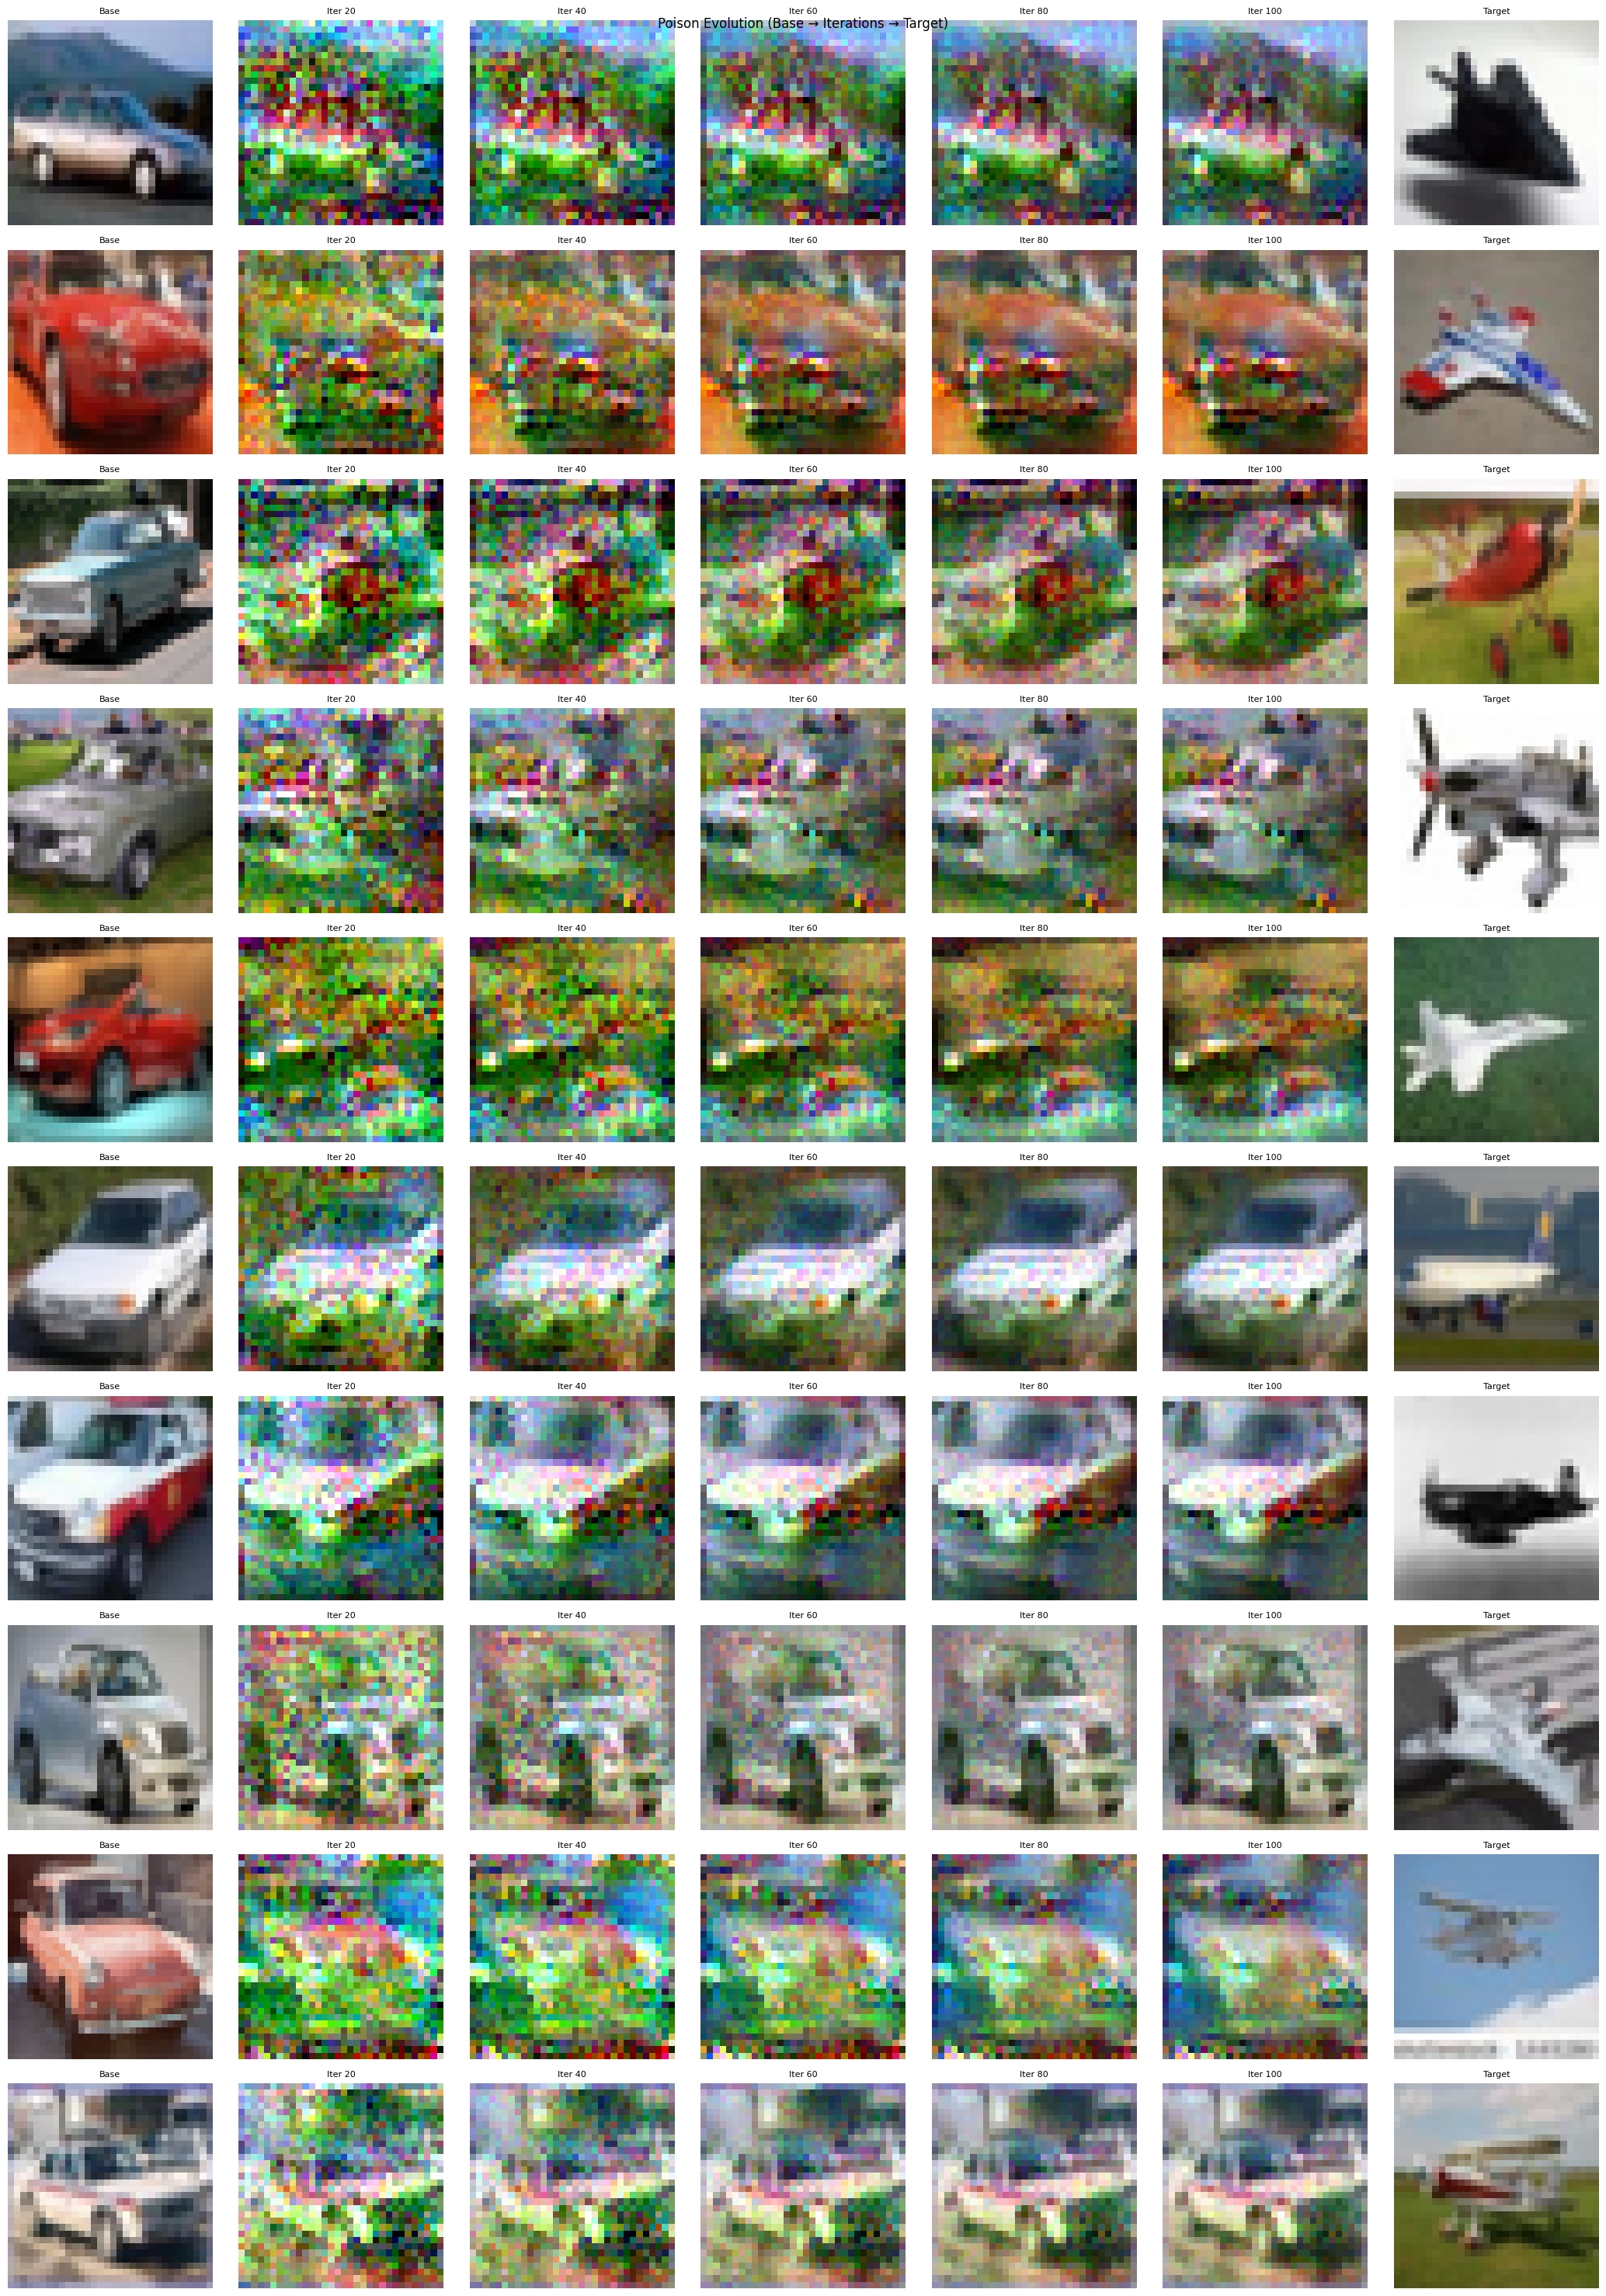

Saved: poisons_evolution.png


In [17]:
BETA       = 0.1    # visual similarity weight
LR_POISON  = 0.05    # Adam LR for poison optimisation
SNAP_ITERS = [20, 40, 60, 80, 100]
ITERATIONS = 100

model.eval()   # freeze model weights during poison generation
poisons = []

N_COLS = 2 + len(SNAP_ITERS)   # base | snaps | target
fig, axes = plt.subplots(NUM_POISONS, N_COLS, figsize=(3*N_COLS, 3*NUM_POISONS))
if NUM_POISONS == 1:
    axes = axes[np.newaxis, :]

for i in range(NUM_POISONS):
    t_img = targets[i].unsqueeze(0).to(device)
    b_img = bases[i].unsqueeze(0).to(device)

    p_img  = b_img.clone().detach().requires_grad_(True)
    opt_p  = optim.Adam([p_img], lr=LR_POISON)
    t_feat = model.get_features(t_img).detach()

    axes[i, 0].imshow(np.transpose(b_img.squeeze().cpu().numpy(), (1,2,0)).clip(0,1))
    axes[i, 0].set_title('Base', fontsize=8); axes[i, 0].axis('off')

    snap_col = 1
    for it in range(1, ITERATIONS + 1):
        opt_p.zero_grad()
        p_feat    = model.get_features(p_img)
        loss_feat = torch.norm(p_feat - t_feat, p=2)**2
        loss_base = torch.norm(p_img  - b_img,  p=2)**2
        (loss_feat + BETA * loss_base).backward()
        opt_p.step()
        with torch.no_grad():
            p_img.clamp_(0.0, 1.0)
        if it in SNAP_ITERS and snap_col < N_COLS - 1:
            axes[i, snap_col].imshow(
                np.transpose(p_img.detach().squeeze().cpu().numpy(),(1,2,0)).clip(0,1))
            axes[i, snap_col].set_title(f'Iter {it}', fontsize=8)
            axes[i, snap_col].axis('off')
            snap_col += 1

    axes[i, -1].imshow(np.transpose(t_img.squeeze().cpu().numpy(),(1,2,0)).clip(0,1))
    axes[i, -1].set_title('Target', fontsize=8); axes[i, -1].axis('off')

    fd = torch.norm(model.get_features(p_img).detach() - t_feat).item()
    print(f'Poison {i+1:2d}  feat_dist={fd:.4f}')
    poisons.append(p_img.detach().cpu().squeeze(0))

fig.suptitle('Poison Evolution (Base → Iterations → Target)')
fig.tight_layout()
plt.savefig('poisons_evolution.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved: poisons_evolution.png')

poisons = torch.stack(poisons)

## 5. Retraining & Evaluation (20 pts)

- Inject all 10 poisons into training set with **label = BASE class (1)**  
- Retrain a **fresh model from scratch** on the poisoned dataset  
- Evaluate: overall accuracy must remain high; targets should now be misclassified as B

In [18]:
# Build poisoned dataset
poison_lbls   = torch.full((NUM_POISONS,), BASE_CLASS, dtype=torch.long)
poisoned_imgs = torch.cat([clean_imgs, poisons])
poisoned_lbls = torch.cat([clean_lbls, poison_lbls])
poisoned_ds   = TensorDataset(poisoned_imgs, poisoned_lbls)
poisoned_loader = DataLoader(poisoned_ds, batch_size=64, shuffle=True)
print(f'Poisoned dataset size: {len(poisoned_ds)}')

# Fresh model — retrain from scratch
poisoned_model = SimpleCNN().to(device)
optimizer_p    = optim.Adam(poisoned_model.parameters(), lr=1e-3)

print('\nRetraining from scratch on poisoned data...')
for ep in range(EPOCHS):
    loss = train_epoch(poisoned_model, poisoned_loader, optimizer_p, criterion)
    if (ep+1) % 5 == 0:
        print(f'  Epoch {ep+1}/{EPOCHS}  loss={loss:.4f}')

print('\nPoisoned Model Evaluation:')
poisoned_acc, poi_pc_cor, poi_pc_tot = evaluate(poisoned_model, test_loader, '[POISONED]')

# Attack success on held-out target images
poisoned_model.eval()
with torch.no_grad():
    preds_poisoned = poisoned_model(targets_dev).argmax(1).cpu().numpy()

success_rate = float(np.mean(preds_poisoned == BASE_CLASS)) * 100.0
print(f'\nTarget predictions (poisoned model): {preds_poisoned}')
print(f'Attack Success Rate: {success_rate:.2f}%  (targets misclassified as {BASE_CLASS}={CLASS_NAMES[BASE_CLASS]})')

Poisoned dataset size: 2000

Retraining from scratch on poisoned data...
  Epoch 5/20  loss=0.7197
  Epoch 10/20  loss=0.5006
  Epoch 15/20  loss=0.3657
  Epoch 20/20  loss=0.2054

Poisoned Model Evaluation:
[POISONED] Overall: 70.95%
  Class 0 (Airplane): 70.70%
  Class 1 (Automobile): 96.10%
  Class 2 (Bird): 42.60%
  Class 3 (Cat): 74.40%

Target predictions (poisoned model): [3 0 0 0 0 1 0 0 2 0]
Attack Success Rate: 10.00%  (targets misclassified as 1=Automobile)


## 6. Report Results (40 pts) — Visualisations & Summary

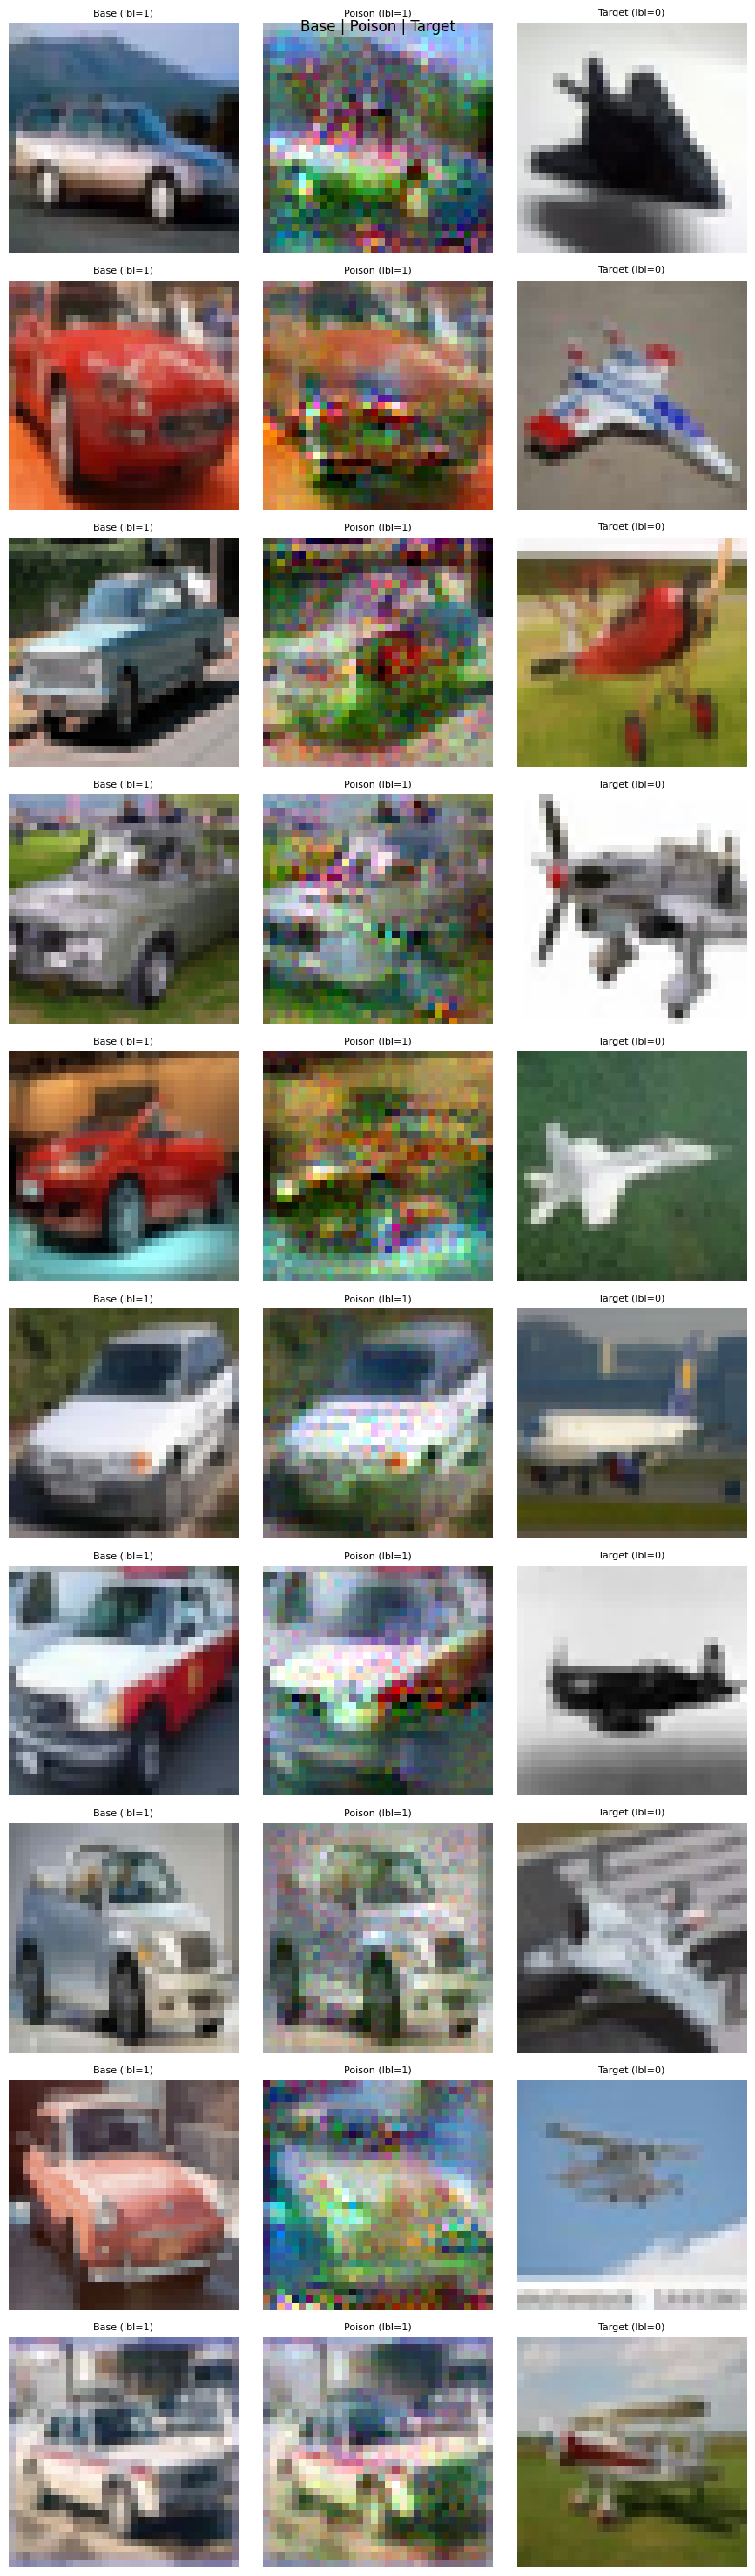

Saved: final_poisons.png


In [19]:
# ── Side-by-side: Base | Poison | Target ────────────────────────────────────
fig2, axes2 = plt.subplots(NUM_POISONS, 3, figsize=(9, 3*NUM_POISONS))
if NUM_POISONS == 1:
    axes2 = axes2[np.newaxis, :]
for i in range(NUM_POISONS):
    axes2[i,0].imshow(np.transpose(bases[i].numpy(),(1,2,0)).clip(0,1))
    axes2[i,0].set_title(f'Base (lbl={BASE_CLASS})', fontsize=8); axes2[i,0].axis('off')
    axes2[i,1].imshow(np.transpose(poisons[i].numpy(),(1,2,0)).clip(0,1))
    axes2[i,1].set_title(f'Poison (lbl={BASE_CLASS})', fontsize=8); axes2[i,1].axis('off')
    axes2[i,2].imshow(np.transpose(targets[i].numpy(),(1,2,0)).clip(0,1))
    axes2[i,2].set_title(f'Target (lbl={TARGET_CLASS})', fontsize=8); axes2[i,2].axis('off')
fig2.suptitle('Base | Poison | Target')
fig2.tight_layout()
plt.savefig('final_poisons.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved: final_poisons.png')

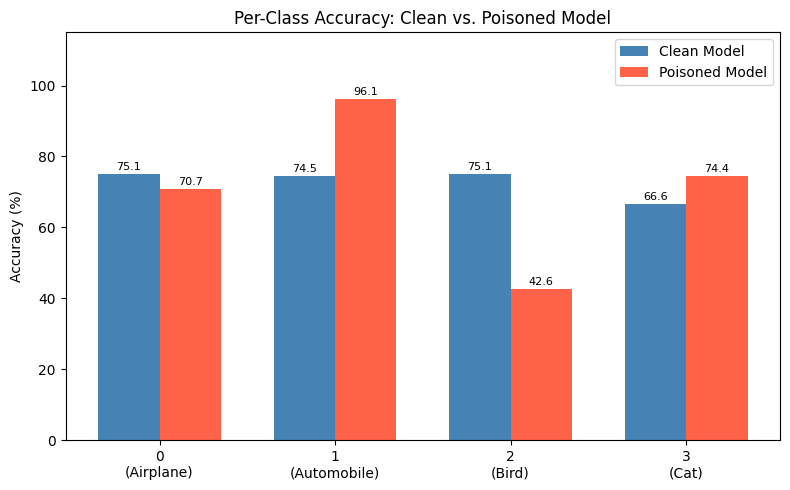

Saved: accuracy_comparison.png


In [20]:
# ── Per-class accuracy bar chart ─────────────────────────────────────────────
x = np.arange(4); width = 0.35
c_accs = [100*clean_pc_cor[i]/clean_pc_tot[i] if clean_pc_tot[i] else 0 for i in range(4)]
p_accs = [100*poi_pc_cor[i]/poi_pc_tot[i] if poi_pc_tot[i] else 0 for i in range(4)]

fig3, ax = plt.subplots(figsize=(8, 5))
b1 = ax.bar(x - width/2, c_accs, width, label='Clean Model',    color='steelblue')
b2 = ax.bar(x + width/2, p_accs, width, label='Poisoned Model', color='tomato')
ax.set_xticks(x)
ax.set_xticklabels([f'{i}\n({CLASS_NAMES[i]})' for i in range(4)])
ax.set_ylabel('Accuracy (%)')
ax.set_title('Per-Class Accuracy: Clean vs. Poisoned Model')
ax.set_ylim(0, 115)
ax.legend()
for b in list(b1)+list(b2):
    ax.annotate(f'{b.get_height():.1f}',
                xy=(b.get_x()+b.get_width()/2, b.get_height()),
                xytext=(0,3), textcoords='offset points', ha='center', fontsize=8)
fig3.tight_layout()
plt.savefig('accuracy_comparison.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved: accuracy_comparison.png')

In [21]:
# ── Save text results ─────────────────────────────────────────────────────────
results = (
    f'=== CS 228 Assignment 2 Results ===\n\n'
    f'Target class : {TARGET_CLASS} ({CLASS_NAMES[TARGET_CLASS]})\n'
    f'Base class   : {BASE_CLASS} ({CLASS_NAMES[BASE_CLASS]})\n'
    f'Num poisons  : {NUM_POISONS}\n\n'
    f'Clean Model Accuracy   : {clean_acc:.2f}%\n'
    + ''.join(f'  Class {i} ({CLASS_NAMES[i]}): {100*clean_pc_cor[i]/clean_pc_tot[i]:.2f}%\n'
              for i in range(4) if clean_pc_tot[i])
    + f'\nPoisoned Model Accuracy: {poisoned_acc:.2f}%\n'
    + ''.join(f'  Class {i} ({CLASS_NAMES[i]}): {100*poi_pc_cor[i]/poi_pc_tot[i]:.2f}%\n'
              for i in range(4) if poi_pc_tot[i])
    + f'\nTarget preds (clean model)   : {preds_clean}\n'
    f'Target preds (poisoned model): {preds_poisoned}\n'
    f'Attack Success Rate          : {success_rate:.2f}%\n'
)
with open('results.txt', 'w') as f:
    f.write(results)
print(results)

=== CS 228 Assignment 2 Results ===

Target class : 0 (Airplane)
Base class   : 1 (Automobile)
Num poisons  : 10

Clean Model Accuracy   : 72.83%
  Class 0 (Airplane): 75.10%
  Class 1 (Automobile): 74.50%
  Class 2 (Bird): 75.10%
  Class 3 (Cat): 66.60%

Poisoned Model Accuracy: 70.95%
  Class 0 (Airplane): 70.70%
  Class 1 (Automobile): 96.10%
  Class 2 (Bird): 42.60%
  Class 3 (Cat): 74.40%

Target preds (clean model)   : [3 0 2 0 0 0 0 0 2 0]
Target preds (poisoned model): [3 0 0 0 0 1 0 0 2 0]
Attack Success Rate          : 10.00%



## Adding result analysis

**Why does the attack (sometimes) fail?**

1. **Limited capacity**: The small CNN may not fully memorise the feature collision introduced by 10 poisons when retrained from scratch.
2. **β trade-off**: A low β allows the poison to drift far from the base visually, but a high β prevents deep feature collision. The optimal value depends on the model and dataset.
3. **Number of poisons**: Clean-label attacks are generally stronger when more poison images are used per target. With only 10 poisons across 10 targets (1 per target), the gradient signal may be insufficient.
4. **Retraining vs fine-tuning**: Retraining from scratch is harder to poison than fine-tuning because the network re-learns all features, diluting the poisoning effect.

**What the plots show:**
- The **poison evolution** plot confirms the poison image gradually adopts features of the target while remaining visually similar to the base.
- The **accuracy comparison** chart shows the poisoned model retains high overall accuracy — confirming the *stealthy* nature of clean-label attacks.
- The **attack success rate** measures what fraction of held-out target images are misclassified as the base class.